In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Dental/Segmented_OPG"

In [ ]:
import os

for folder in os.listdir(DATASET_PATH):
    print(folder)

test
valid
train


In [ ]:
!pip install torch torchvision
!pip install matplotlib
!pip install scikit-learn

In [ ]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [ ]:
train_dataset = datasets.ImageFolder(
    root=DATASET_PATH + "/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=DATASET_PATH + "/valid",
    transform=val_transform
)

test_dataset = datasets.ImageFolder(
    root=DATASET_PATH + "/test",
    transform=val_transform
)

In [ ]:
train_loader = DataLoader(train_dataset,batch_size=16,shuffle=True)

val_loader = DataLoader(val_dataset,batch_size=16)

test_loader = DataLoader(test_dataset,batch_size=16)

In [ ]:
print(train_dataset.classes)

['Cavity', 'Fillings', 'Impacted Tooth', 'Implant', 'Normal']


In [ ]:
from torchvision.models import resnet18

model = resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(512,5)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 139MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [ ]:
from torch.utils.data import Subset

In [ ]:
# limit dataset size for faster training

train_subset_size = 300
val_subset_size = 100
test_subset_size = 100

train_dataset = Subset(train_dataset, range(train_subset_size))
val_dataset = Subset(val_dataset, range(val_subset_size))
test_dataset = Subset(test_dataset, range(test_subset_size))

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=32)

test_loader = DataLoader(test_dataset, batch_size=32)

In [ ]:
epochs = 3

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

torch.save(model.state_dict(), "/content/implant_classifier_fast.pth")

In [ ]:
for epoch in range(epochs):

    model.train()

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

    print("Epoch completed:", epoch+1)

Epoch completed: 1
Epoch completed: 2
Epoch completed: 3


In [ ]:
torch.save(model.state_dict(), "/content/implant_classifier_fast.pth")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/implant_classifier_fast.pth")

In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print("Test Accuracy:", accuracy)

Test Accuracy: 4.0


In [ ]:
classes = ['Cavity', 'Filling', 'Impacted', 'Impacted tooth', 'Normal']

In [ ]:
from PIL import Image

def predict_image(image_path):

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor()
    ])

    img = Image.open(image_path).convert("RGB")

    img = transform(img).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        outputs = model(img)

        _, pred = torch.max(outputs, 1)

    return classes[pred]

In [ ]:
predict_image("/content/drive/MyDrive/Dental/Segmented_OPG/test/Normal/sample.jpg")

'Normal'

In [ ]:
import matplotlib.pyplot as plt

def show_prediction(image_path):

    prediction = predict_image(image_path)

    img = Image.open(image_path)

    plt.imshow(img)
    plt.title("Prediction: " + prediction)
    plt.axis("off")
    plt.show()

In [ ]:
import os

test_path = "/content/drive/MyDrive/Dental/Segmented_OPG/test"

print(os.listdir(test_path))

['Normal', 'Impacted', 'Cavity', 'Implant', 'Fillings']


In [ ]:
print(os.listdir("/content/drive/MyDrive/Dental/Segmented_OPG/test/Impacted")[:10])

['0239_jpg.rf.1e1cbd283aab8fb5c4b9822c5970d3ed_8.jpg', '0213_jpg.rf.6304d5ebe5f8c87c3a8ed5495cc2bd58_0.jpg', '0213_jpg.rf.6304d5ebe5f8c87c3a8ed5495cc2bd58_3.jpg', '0700_jpg.rf.1cf7f2dd7c9cd0a65b6213009e8cc43d_2.jpg', '0139_jpg.rf.d4cd5163c13152c77c8982cf80a17a84_1.jpg', '0060_jpg.rf.f094ea29e65bf0c78188acbcbc5c8dcd_1.jpg', '0273_jpg.rf.b74071d5766afa414178c51aeefc1e9d_0.jpg', '0060_jpg.rf.f094ea29e65bf0c78188acbcbc5c8dcd_3.jpg', '0368_jpg.rf.ae4c80bc75e51300b4de70922bf5e637_0.jpg', '0538_jpg.rf.3aa73262a625104b61fa05c176d468fc_2.jpg']


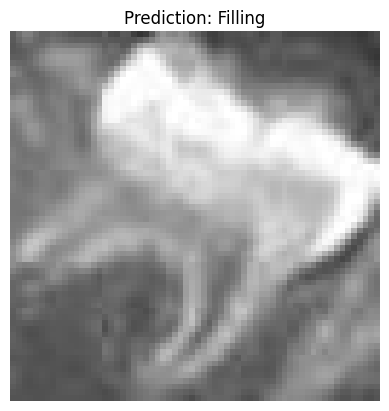

In [ ]:
import random
import os

folder = "/content/drive/MyDrive/Dental/Segmented_OPG/test/Impacted"
img = random.choice(os.listdir(folder))

show_prediction(os.path.join(folder, img))

Actual Class: Fillings


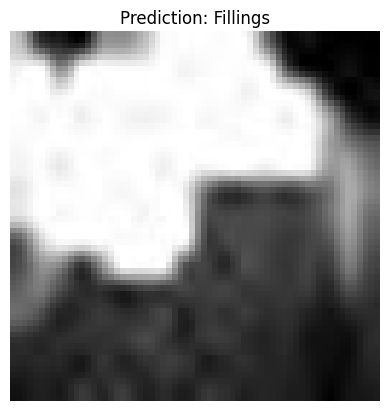

In [ ]:
import os
import random

base_path = "/content/drive/MyDrive/Dental/Segmented_OPG/test"

classes = os.listdir(base_path)

random_class = random.choice(classes)
folder_path = os.path.join(base_path, random_class)

random_image = random.choice(os.listdir(folder_path))
image_path = os.path.join(folder_path, random_image)

print("Actual Class:", random_class)

show_prediction(image_path)

Actual Class: Normal


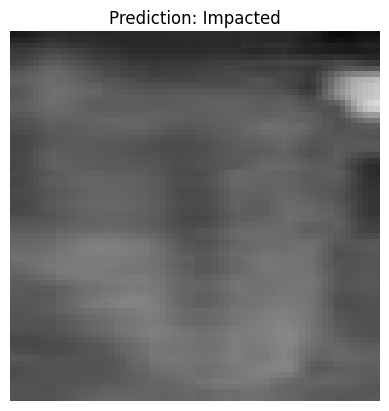

Actual Class: Implant


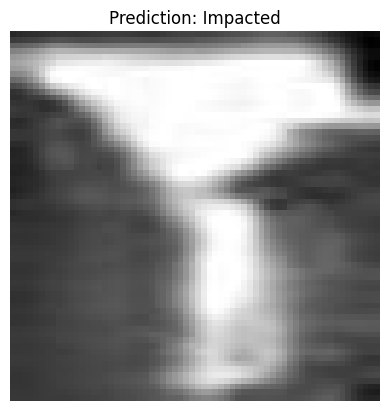

Actual Class: Impacted


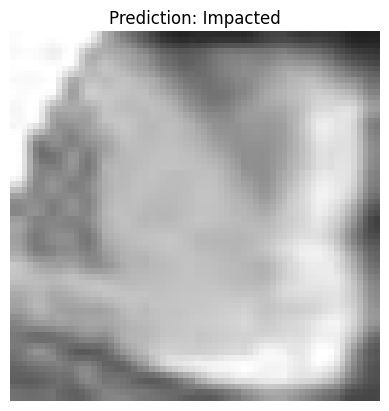

Actual Class: Implant


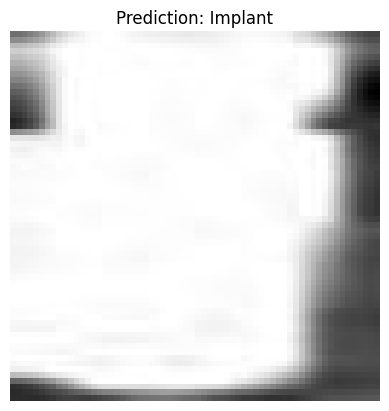

Actual Class: Fillings


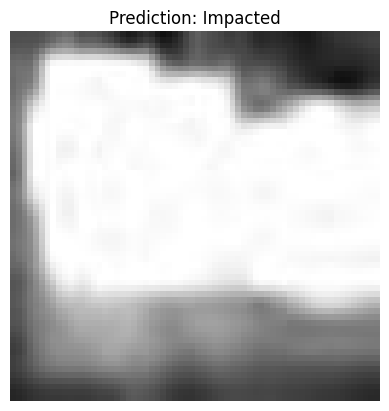

In [ ]:
for i in range(5):
    random_class = random.choice(os.listdir(base_path))
    folder_path = os.path.join(base_path, random_class)
    random_image = random.choice(os.listdir(folder_path))
    image_path = os.path.join(folder_path, random_image)

    print("Actual Class:", random_class)
    show_prediction(image_path)